#📊 Project Title: Global Terrorism Trends Analysis (1970–2020)
#🔍Objective:
## To explore, analyze, and visualize global terrorism patterns using the GTD dataset, with insights into geography, time, attack types, and regional hotspots.

download the Dataset- https://drive.google.com/file/d/19PlBcrWZJFsdoSnGNMnxIcsxL4aiLBzc/view?usp=drive_link#

Import Libraries & Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,3)

In [46]:
# Load the dataset
df=pd.read_csv("/content/drive/MyDrive/Projects/EDA2/globalterrorismdb.csv",encoding='ISO-8859-1', low_memory=False)
df.head(5)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [47]:
# Basic overview
print("Shape:", df.shape)

Shape: (209706, 135)


In [48]:
# To Check all Columns
print("Columns:", df.columns.tolist())

Columns: ['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2

In [49]:
# Data Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209706 entries, 0 to 209705
Columns: 135 entries, eventid to related
dtypes: float64(54), int64(23), object(58)
memory usage: 216.0+ MB
None


In [50]:
# Total Country in the Dataset
print(df['country_txt'].nunique())

204


In [51]:
# Various Attack Types
print(df['attacktype1_txt'].unique())
print(df['attacktype1_txt'].nunique())

['Assassination' 'Hostage Taking (Kidnapping)' 'Bombing/Explosion'
 'Facility/Infrastructure Attack' 'Armed Assault' 'Hijacking' 'Unknown'
 'Unarmed Assault' 'Hostage Taking (Barricade Incident)']
9


In [11]:
# Terror Groups by Number of Attacks
print(df[df['gname'] != 'Unknown']['gname'].value_counts().head(10))

gname
Taliban                                             11982
Islamic State of Iraq and the Levant (ISIL)          7254
Shining Path (SL)                                    4564
Al-Shabaab                                           4419
New People's Army (NPA)                              3395
Farabundo Marti National Liberation Front (FMLN)     3351
Boko Haram                                           3320
Houthi extremists (Ansar Allah)                      3196
Irish Republican Army (IRA)                          2670
Kurdistan Workers' Party (PKK)                       2582
Name: count, dtype: int64


<span style="color:blue; font-weight:bold">Data Cleaning & Preprocessing</span>


In [12]:
# Limiting the Columns

columns_to_keep = ['iyear', 'imonth', 'iday', 'country_txt', 'region_txt',
                   'provstate', 'city', 'attacktype1_txt', 'weaptype1_txt',
                   'targtype1_txt', 'nkill', 'nwound', 'gname']
df = df[columns_to_keep]

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209706 entries, 0 to 209705
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iyear            209706 non-null  int64  
 1   imonth           209706 non-null  int64  
 2   iday             209706 non-null  int64  
 3   country_txt      209706 non-null  object 
 4   region_txt       209706 non-null  object 
 5   provstate        209706 non-null  object 
 6   city             209279 non-null  object 
 7   attacktype1_txt  209706 non-null  object 
 8   weaptype1_txt    209706 non-null  object 
 9   targtype1_txt    209706 non-null  object 
 10  nkill            197179 non-null  float64
 11  nwound           189770 non-null  float64
 12  gname            209706 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 20.8+ MB
None


In [15]:
# Rename Columns
df.rename(columns={
    'iyear': 'Year',
    'imonth': 'Month',
    'iday': 'Day',
    'country_txt': 'Country',
    'region_txt': 'Region',
    'provstate': 'State',
    'city': 'City',
    'attacktype1_txt': 'AttackType',
    'targtype1_txt': 'TargetType',
    'weaptype1_txt': 'WeaponType',
    'nkill': 'Killed',
    'nwound': 'Wounded',
    'gname': 'Group'
}, inplace=True)

In [16]:
df.head(2)

,Year,Month,Day,Country,Region,State,City,AttackType,WeaponType,TargetType,Killed,Wounded,Group
0,1970,7,2,Dominican Republic,Central America & Caribbean,National,Santo Domingo,Assassination,Unknown,Private Citizens & Property,1.0,0.0,MANO-D
1,1970,0,0,Mexico,North America,Federal,Mexico city,Hostage Taking (Kidnapping),Unknown,Government (Diplomatic),0.0,0.0,23rd of September Communist League


In [18]:
# Checking Null
print(df.isnull().sum().sort_values(ascending=False).head(10))

Wounded       19936
Killed        12527
City            427
Month             0
Year              0
Region            0
Country           0
Day               0
State             0
WeaponType        0
dtype: int64


In [36]:
# Handling missing values
df['City'] = df['City'].fillna('Unknown')
df['Killed'] = df['Killed'].fillna(0)
df['Wounded'] = df['Wounded'].fillna(0)

In [52]:
# Adding new Column
df['Casualties'] = df['Killed'] + df['Wounded']

In [21]:
df.head(2)

,Year,Month,Day,Country,Region,State,City,AttackType,WeaponType,TargetType,Killed,Wounded,Group,Casualties
0,1970,7,2,Dominican Republic,Central America & Caribbean,National,Santo Domingo,Assassination,Unknown,Private Citizens & Property,1.0,0.0,MANO-D,1.0
1,1970,0,0,Mexico,North America,Federal,Mexico city,Hostage Taking (Kidnapping),Unknown,Government (Diplomatic),0.0,0.0,23rd of September Communist League,0.0


**Exploratory Data Analysis**

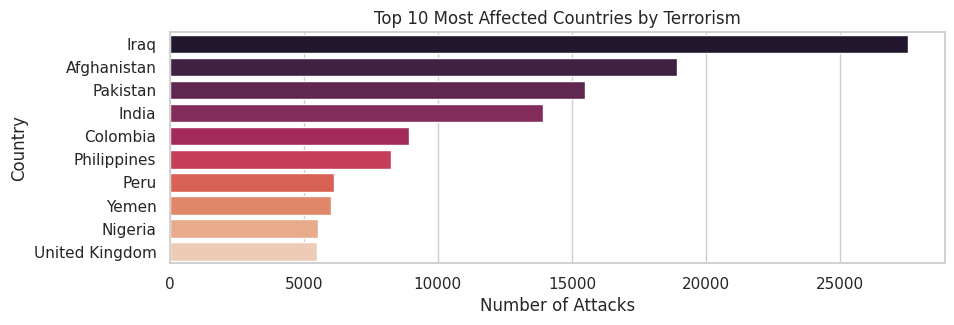

In [38]:
# Top 10 affected countries
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values,y=top_countries.index,hue=top_countries.index,palette='rocket',legend=False)
plt.title("Top 10 Most Affected Countries by Terrorism")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")
plt.show()

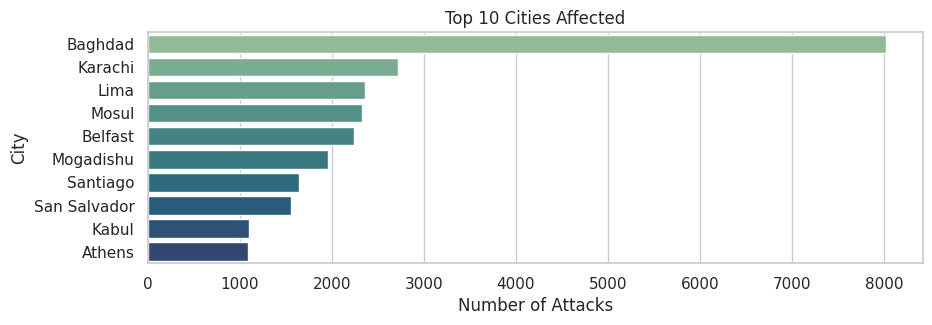

In [ ]:
# # Top 10 affected City
top_cities = df[df['City'] != 'Unknown']['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index,hue=top_countries.index,palette='crest',legend=False)
plt.title('Top 10 Cities Affected')
plt.xlabel('Number of Attacks')
plt.ylabel('City')
plt.show()

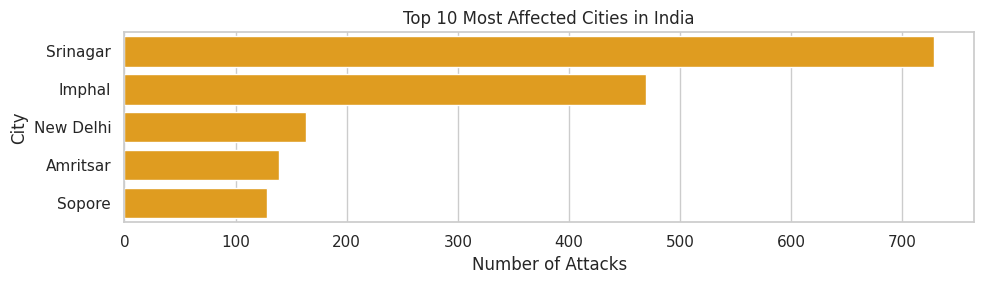

In [ ]:
# Get top 5 most attacked Indian cities
india_df = df[(df['Country'] == 'India') & (df['City'] != 'Unknown')]
top_indian_cities = india_df['City'].value_counts().head(5)
# Plot
sns.barplot(x=top_indian_cities.values, y=top_indian_cities.index,color="orange")
plt.title('Top 5 Most Affected Cities in India')
plt.xlabel('Number of Attacks')
plt.ylabel('City')
plt.tight_layout()
plt.show()

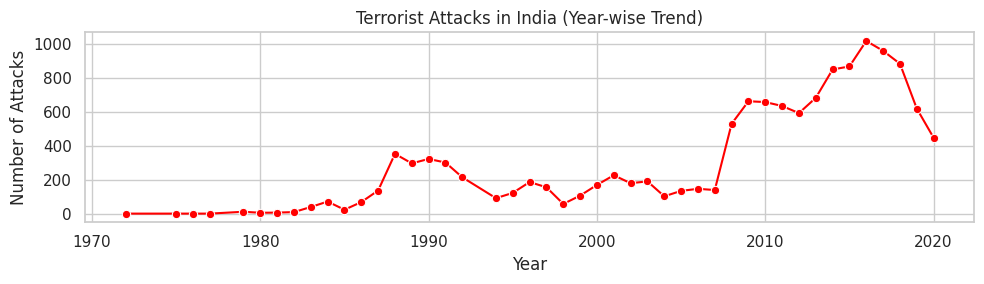

In [ ]:
# Attacks by Year in India.
attacks_by_year = india_df.groupby('Year').size().reset_index(name='Attack_Count')
# Plot
sns.lineplot(data=attacks_by_year, x='Year', y='Attack_Count', marker='o', color='red')
plt.title('Terrorist Attacks in India (Year-wise Trend)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.tight_layout()
plt.show()

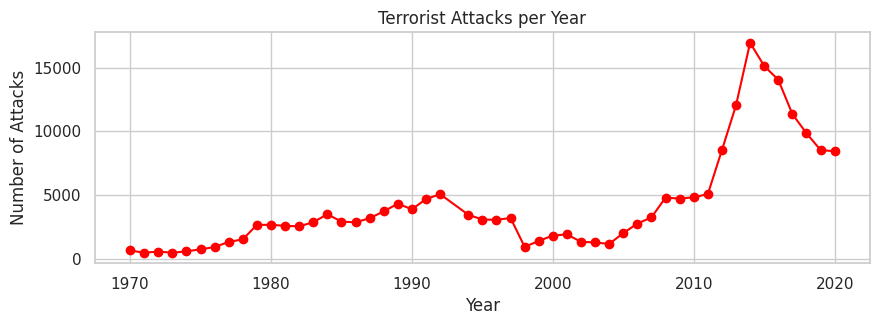

In [ ]:
# Terror attacks over years world_wide
attacks_per_year = df['Year'].value_counts().sort_index()
plt.plot(attacks_per_year.index,attacks_per_year.values,color='red',marker='o')
plt.title("Terrorist Attacks per Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.grid(True)
plt.show()

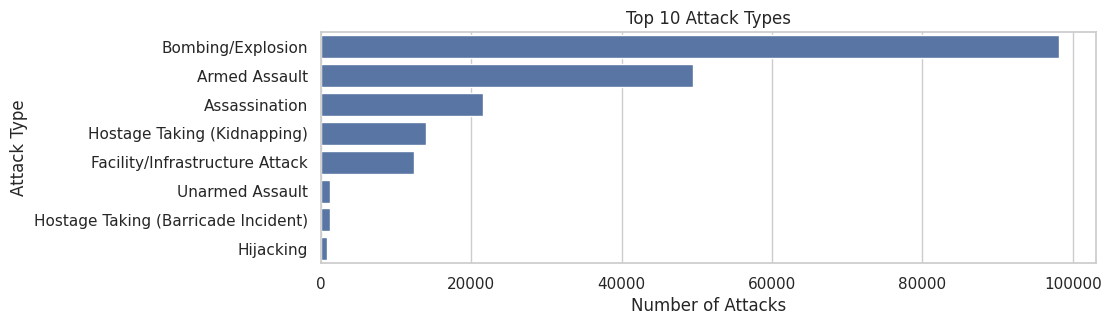

In [ ]:
# Common attack types
filtered_df = df[df['AttackType'] != 'Unknown']
attack_counts = filtered_df['AttackType'].value_counts()
sns.barplot(x=attack_counts.values[:10], y=attack_counts.index[:10])
plt.title("Top 10 Attack Types")
plt.xlabel("Number of Attacks")
plt.ylabel("Attack Type")
plt.show()

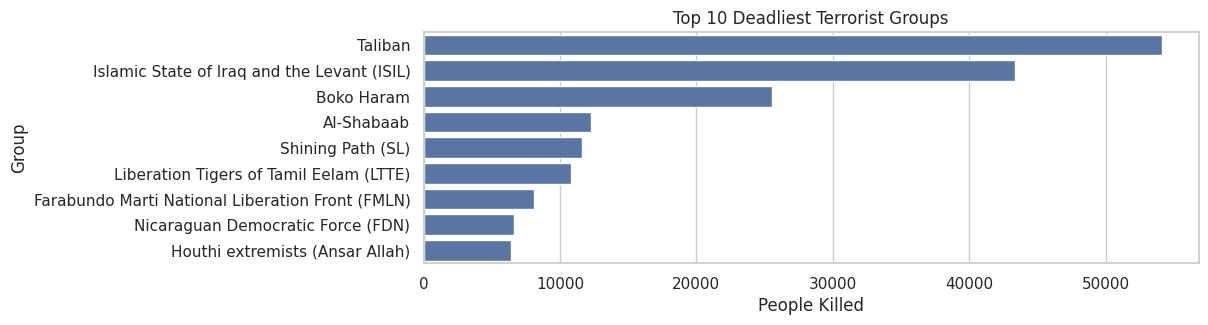

In [ ]:
# Deadliest terrorist groups
deadliest_groups = df.groupby('Group')['Killed'].sum().sort_values(ascending=False).head(10)
deadliest_groups = deadliest_groups[deadliest_groups.index != 'Unknown']
sns.barplot(x=deadliest_groups.values, y=deadliest_groups.index)
plt.title("Top 10 Deadliest Terrorist Groups")
plt.xlabel("People Killed")
plt.ylabel("Group")
plt.show()

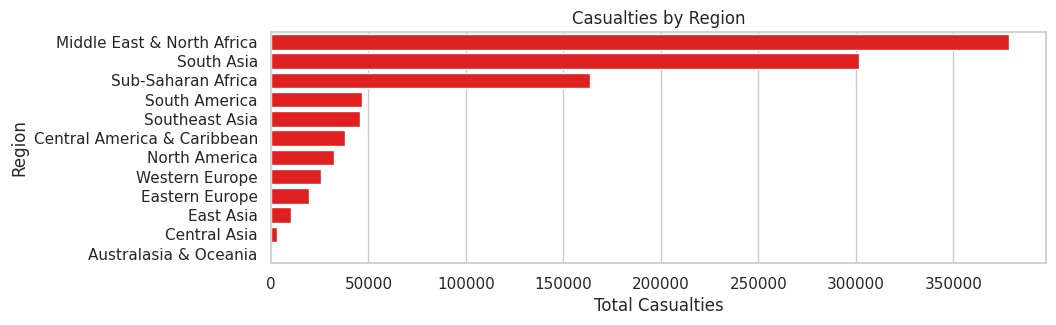

In [ ]:
# Region-wise casualties
region_casualties =df.groupby('Region')['Casualties'].sum().sort_values(ascending=False)
sns.barplot(x=region_casualties.values,y=region_casualties.index,color="red")
plt.title("Casualties by Region")
plt.xlabel("Total Casualties")
plt.ylabel("Region")
plt.show()

# 🎯 Conclusion from Global Terrorism EDA
**🌍 Top 10 Affected Countries:**

The countries most impacted by terrorism include Iraq, Afghanistan, Pakistan, and India, with Iraq recording the highest number of incidents.

**🏙️ Top 10 Affected Cities (Global):**

Cities like Baghdad, Karachi, Lima, and Mosul have been among the most frequently targeted globally.

**🇮🇳 Top 5 Most Attacked Indian Cities:**

The most targeted Indian cities are Srinagar, Imphal, New Delhi, Amritsar, and Seapore, indicating both conflict-prone and capital regions.

**📈 Terror Attack Trend in India: **

Terrorism in India began to rise in the late 1980s, peaked in 2016, and has declined steadily since then.

**🌐 Global Terrorism Trend:**

Worldwide attacks saw a rise from the 1980s, peaked around 2014, and have been on a decline since.

**💣 Most Common Attack Types:**

Predominant methods include Bombings/Explosions, Armed Assaults, and Assassinations.

**☠️ Deadliest Terrorist Groups:**

The groups responsible for the highest number of attacks globally are Taliban, Islamic State of Iraq and the Levant (ISIL), and Boko Haram.

**🗺️ Most Affected Region:**

The Middle East and North Africa region has suffered the highest number of casualties, making it the most affected by terrorism globally.